# Exploratory Analysis

This notebook connects to the SQLite database and explores the key commercial findings from the SQL analysis using Python visualisations.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../Data/commercial_returns.db")

In [3]:
pd.read_sql_query("""
SELECT COUNT(*) AS total_rows
FROM orders;
""", conn)

,total_rows
0,51290


## Sales Performance Visualisations

This section visualises category-level sales and profit performance using SQL query results loaded into Pandas.

In [4]:
sales_by_category = pd.read_sql_query("""
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS total_sales
FROM orders
GROUP BY Category
ORDER BY total_sales DESC;
""", conn)

sales_by_category

,Category,total_sales
0,Technology,4744557.50
1,Furniture,4110451.90
2,Office Supplies,3787492.51


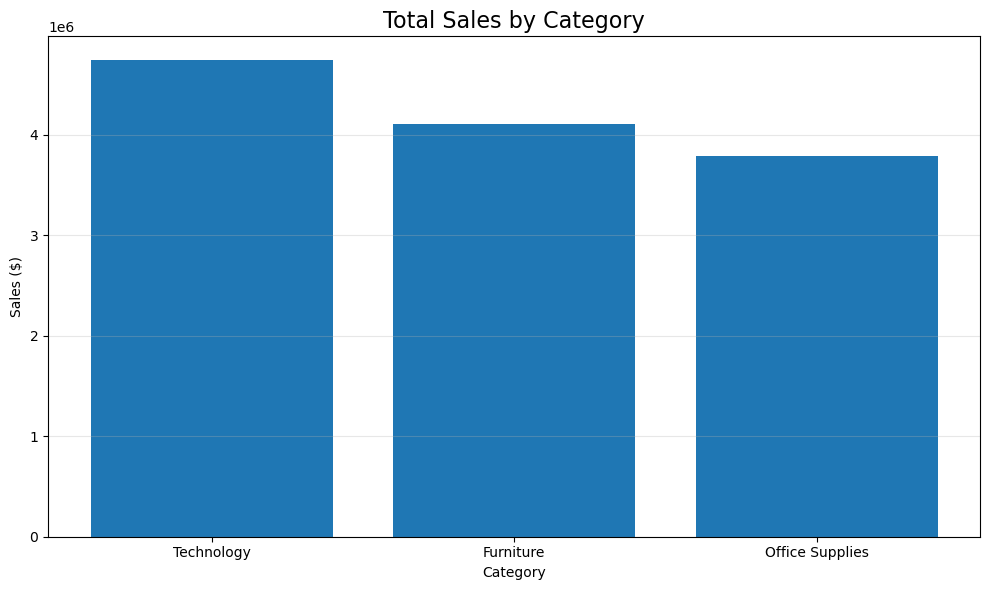

In [5]:
plt.figure(figsize=(10,6))

plt.bar(
    sales_by_category["Category"],
    sales_by_category["total_sales"]
)

plt.title("Total Sales by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../Images/sales_by_category.png", dpi=300)

plt.show()

## Profit Performance

This section analyses profitability across each product category.

In [6]:
profit_by_category = pd.read_sql_query("""
SELECT
    Category,
    ROUND(SUM(Profit), 2) AS total_profit
FROM orders
GROUP BY Category
ORDER BY total_profit DESC;
""", conn)

profit_by_category

,Category,total_profit
0,Technology,663778.73
1,Office Supplies,518595.83
2,Furniture,285082.73


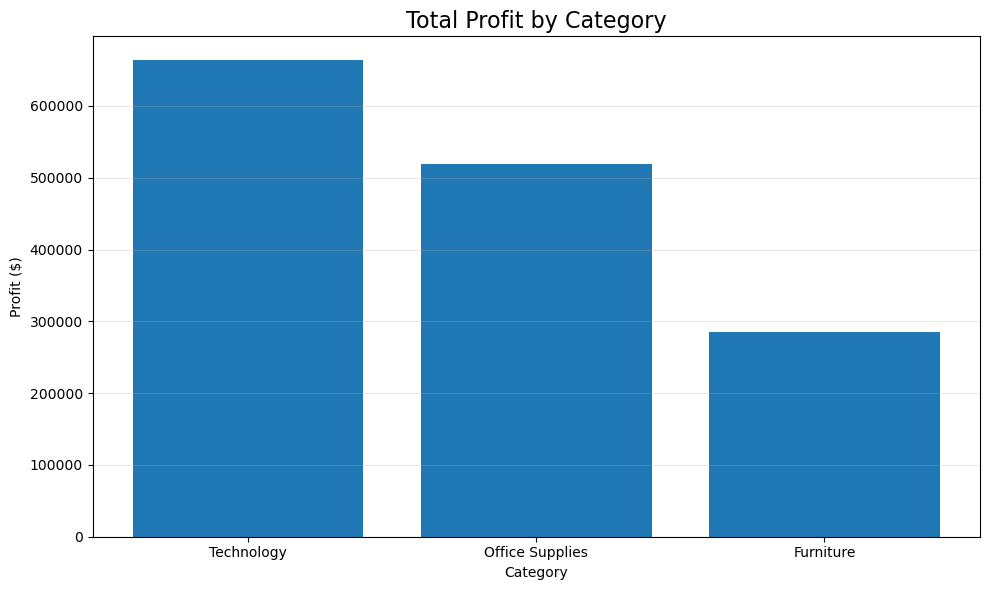

In [7]:
plt.figure(figsize=(10,6))

plt.bar(
    profit_by_category["Category"],
    profit_by_category["total_profit"]
)

plt.title("Total Profit by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../Images/profit_by_category.png", dpi=300)

plt.show()

## Return Rate by Category

This section visualises return rates across product categories to identify where returns are most concentrated.

In [8]:
return_rate_by_category = pd.read_sql_query("""
SELECT
    o.Category,
    COUNT(DISTINCT r."Order ID") AS returned_orders,
    COUNT(DISTINCT o."Order ID") AS total_orders,
    ROUND(
        COUNT(DISTINCT r."Order ID") * 100.0 /
        COUNT(DISTINCT o."Order ID"),
        2
    ) AS return_rate_percent
FROM orders o
LEFT JOIN returns r
ON o."Order ID" = r."Order ID"
GROUP BY o.Category
ORDER BY return_rate_percent DESC;
""", conn)

return_rate_by_category

,Category,returned_orders,total_orders,return_rate_percent
0,Furniture,836,8222,10.17
1,Technology,849,8428,10.07
2,Office Supplies,1677,19464,8.62


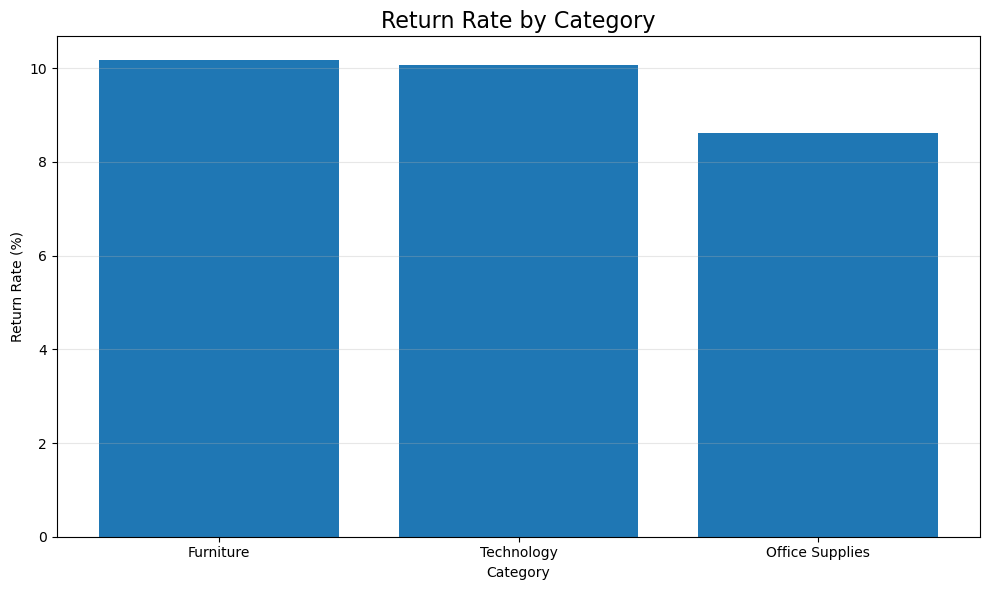

In [9]:
plt.figure(figsize=(10,6))

plt.bar(
    return_rate_by_category["Category"],
    return_rate_by_category["return_rate_percent"]
)

plt.title("Return Rate by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../Images/return_rate_by_category.png", dpi=300)

plt.show()

## Financial Impact of Returns

This section visualises the total sales associated with returned orders, providing an indication of the commercial value linked to customer returns.

In [10]:
returned_sales = pd.read_sql_query("""
SELECT
    o.Category,
    ROUND(SUM(o.Sales),2) AS returned_sales
FROM orders o
INNER JOIN returns r
ON o."Order ID" = r."Order ID"
GROUP BY o.Category
ORDER BY returned_sales DESC;
""", conn)

returned_sales

,Category,returned_sales
0,Technology,507012.06
1,Furniture,500608.31
2,Office Supplies,446805.73


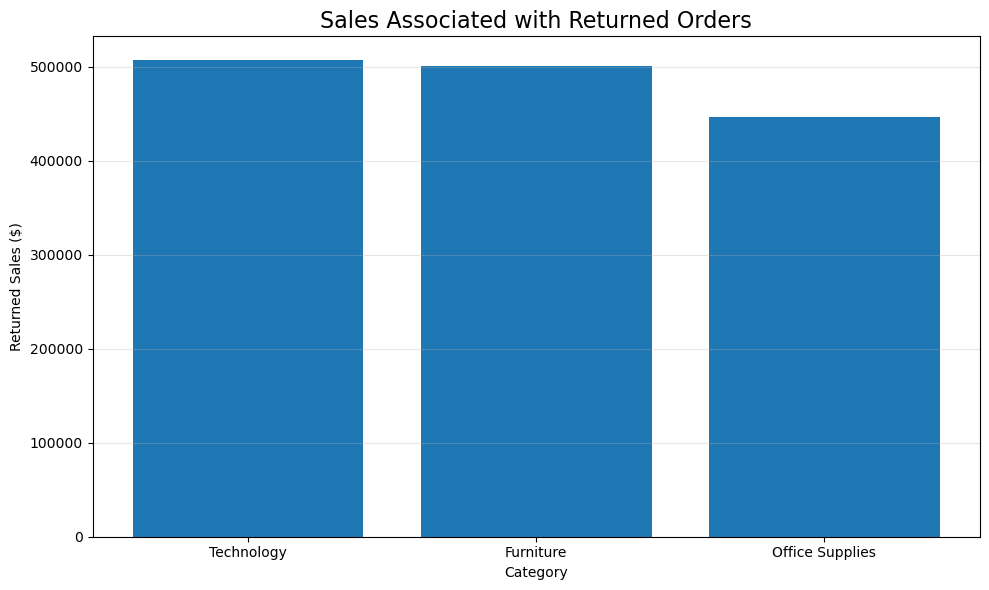

In [11]:
plt.figure(figsize=(10,6))

plt.bar(
    returned_sales["Category"],
    returned_sales["returned_sales"]
)

plt.title("Sales Associated with Returned Orders", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Returned Sales ($)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../Images/returned_sales_by_category.png", dpi=300)

plt.show()

## Profit Margin by Category

This section compares profit margins across product categories to identify which categories convert sales into profit most effectively.

In [12]:
profit_margin = pd.read_sql_query("""
SELECT
    Category,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS profit_margin
FROM orders
GROUP BY Category
ORDER BY profit_margin DESC;
""", conn)

profit_margin

,Category,profit_margin
0,Technology,13.99
1,Office Supplies,13.69
2,Furniture,6.94


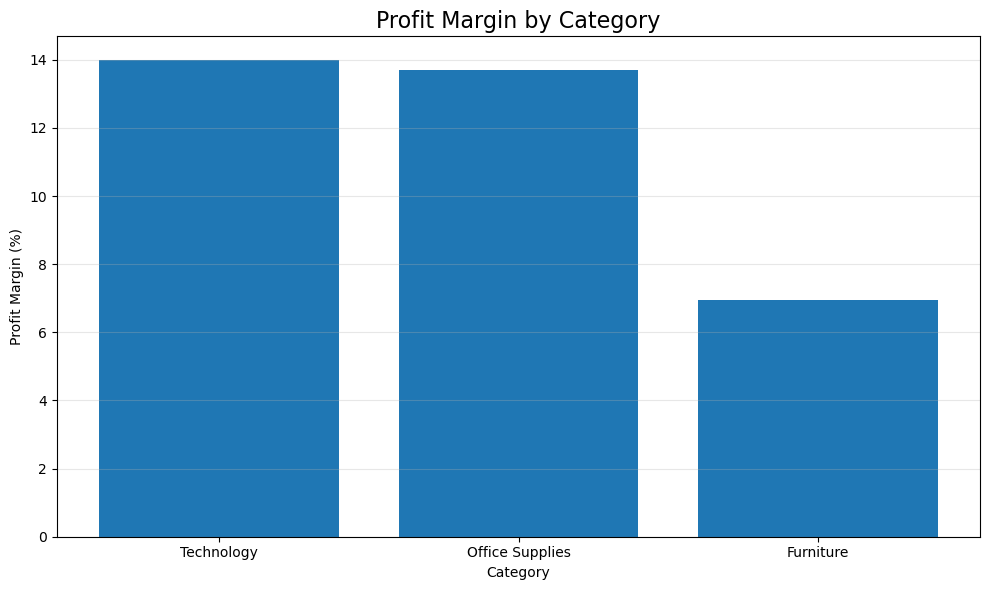

In [13]:
plt.figure(figsize=(10,6))

plt.bar(
    profit_margin["Category"],
    profit_margin["profit_margin"]
)

plt.title("Profit Margin by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../Images/profit_margin_by_category.png", dpi=300)

plt.show()